# Tendencia e decomposicao

**Objetivo:** separar a serie observada em componentes mais interpretaveis para responder duas perguntas centrais:
- existe crescimento ou queda estrutural ao longo do tempo?
- o padrao sazonal parece estavel ou muda bastante entre os anos?

Como a serie e diaria e ja mostrou padroes de calendario semanais e anuais, vamos priorizar uma decomposicao do tipo **MSTL** quando ela estiver disponivel no ambiente. Esse metodo permite decompor a serie em:
- tendencia de longo prazo;
- sazonalidade semanal;
- sazonalidade anual;
- residuo, que representa a parte nao explicada pelos componentes anteriores.

Se o `MSTL` nao estiver disponivel, o codigo cai automaticamente para uma decomposicao `STL` semanal, para manter a secao executavel.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from statsmodels.tsa.seasonal import MSTL
    metodo_decomposicao = "MSTL"
except ImportError:
    from statsmodels.tsa.seasonal import STL
    metodo_decomposicao = "STL"

In [5]:
meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

dias_semana = {
    0: "Seg", 1: "Ter", 2: "Qua", 3: "Qui", 4: "Sex", 5: "Sab", 6: "Dom"
}

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [ ]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.csv"

df_internacoes = pd.read_csv(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

## Tendencia e decomposicao

In [3]:
# Preparamos a serie diaria com indice temporal regular.
serie_decomp = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

# Caso haja lacunas na serie, interpolamos apenas para viabilizar a decomposicao.
faltantes_decomp = int(serie_decomp.isna().sum())
if faltantes_decomp > 0:
    print(f"Foram encontrados {faltantes_decomp} dias faltantes. A serie sera interpolada para a decomposicao.")
    serie_decomp = serie_decomp.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a decomposicao.")

print("Metodo selecionado:", metodo_decomposicao)
display(serie_decomp.head().to_frame(name="num_internacoes"))

Nenhum dia faltante foi encontrado para a decomposicao.
Metodo selecionado: MSTL


,num_internacoes
data_dia,
2012-01-01,234
2012-01-02,336
2012-01-03,198
2012-01-04,192
2012-01-05,186


### Ajuste da decomposicao

Nesta etapa o modelo separa a serie em tendencia, sazonalidade e residuo. No caso do `MSTL`, teremos duas sazonalidades explicitas: uma de **7 dias** e outra de **365 dias**.

In [6]:
if metodo_decomposicao == "MSTL":
    periodos_decomposicao = (7, 365)
    resultado_decomp = MSTL(
        serie_decomp,
        periods=periodos_decomposicao,
        stl_kwargs={"robust": True},
    ).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal["seasonal_7"]
    df_decomp["sazonal_365"] = resultado_decomp.seasonal["seasonal_365"]
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"] + df_decomp["sazonal_365"]
    df_decomp["residuo"] = resultado_decomp.resid
else:
    from statsmodels.tsa.seasonal import STL

    periodos_decomposicao = (7,)
    resultado_decomp = STL(serie_decomp, period=7, robust=True).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal
    df_decomp["sazonal_365"] = np.nan
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"]
    df_decomp["residuo"] = resultado_decomp.resid

# Adicionamos chaves de calendario para resumir e comparar os componentes depois.
df_decomp["ano"] = df_decomp.index.year
df_decomp["mes"] = df_decomp.index.month
df_decomp["mes_nome"] = pd.Categorical(
    df_decomp["mes"].map(meses),
    categories=list(meses.values()),
    ordered=True,
)
df_decomp["dia_semana_num"] = df_decomp.index.dayofweek
df_decomp["dia_semana_nome"] = pd.Categorical(
    df_decomp["dia_semana_num"].map(dias_semana),
    categories=list(dias_semana.values()),
    ordered=True,
)

print("Periodos sazonais considerados:", periodos_decomposicao)
display(df_decomp.head().round(2))

Periodos sazonais considerados: (7, 365)


,observado,tendencia,sazonal_7,sazonal_365,sazonal_total,residuo,ano,mes,mes_nome,dia_semana_num,dia_semana_nome
data_dia,,,,,,,,,,,
2012-01-01,234.0,279.25,-57.74,-108.77,-166.51,121.26,2012,1,Jan,6,Dom
2012-01-02,336.0,279.08,115.41,-51.23,64.18,-7.27,2012,1,Jan,0,Seg
2012-01-03,198.0,278.92,-21.91,-30.50,-52.41,-28.51,2012,1,Jan,1,Ter
2012-01-04,192.0,278.76,-14.97,-38.72,-53.70,-33.06,2012,1,Jan,2,Qua
2012-01-05,186.0,278.59,-6.56,-61.20,-67.75,-24.84,2012,1,Jan,3,Qui


### Visualizacao dos componentes

O objetivo aqui e comparar visualmente a serie observada com a tendencia estimada, ver o comportamento das sazonalidades e inspecionar o residuo. Se o residuo ainda tiver muitos blocos estruturados, isso pode ser sinal de que existem eventos ou quebras que a decomposicao nao capturou.

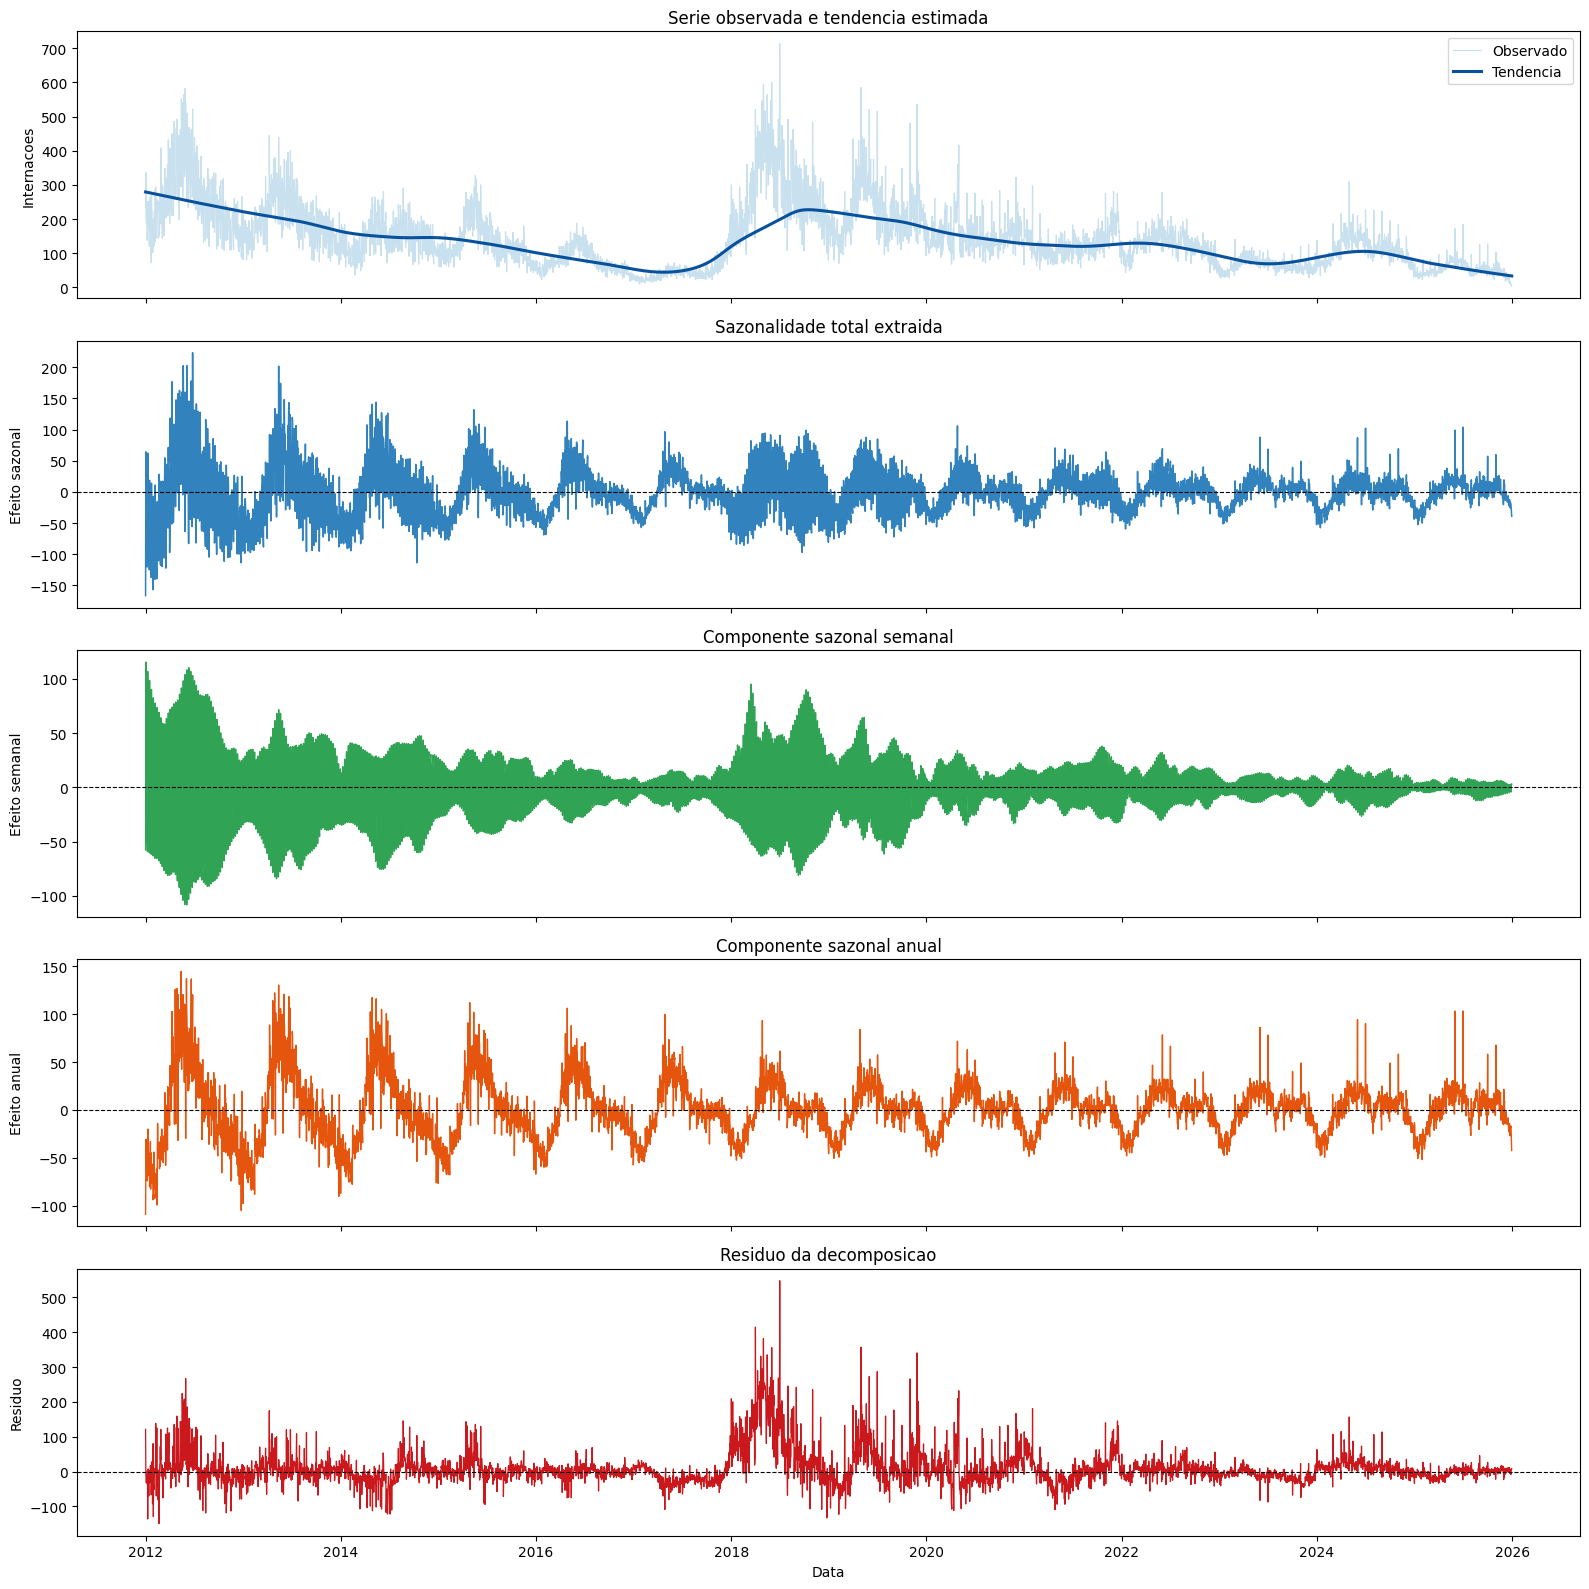

In [8]:
tem_sazonal_anual = df_decomp["sazonal_365"].notna().any()
n_linhas = 5 if tem_sazonal_anual else 4

fig, axes = plt.subplots(n_linhas, 1, figsize=(16, 3.2 * n_linhas), sharex=True)

axes[0].plot(df_decomp.index, df_decomp["observado"], color="#9ecae1", linewidth=0.9, alpha=0.55, label="Observado")
axes[0].plot(df_decomp.index, df_decomp["tendencia"], color="#08519c", linewidth=2.2, label="Tendencia")
axes[0].set_title("Serie observada e tendencia estimada")
axes[0].set_ylabel("Internacoes")
axes[0].legend(loc="upper right")

axes[1].plot(df_decomp.index, df_decomp["sazonal_total"], color="#3182bd", linewidth=1.1)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Sazonalidade total extraida")
axes[1].set_ylabel("Efeito sazonal")

axes[2].plot(df_decomp.index, df_decomp["sazonal_7"], color="#31a354", linewidth=1.0)
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Componente sazonal semanal")
axes[2].set_ylabel("Efeito semanal")

if tem_sazonal_anual:
    axes[3].plot(df_decomp.index, df_decomp["sazonal_365"], color="#e6550d", linewidth=1.0)
    axes[3].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[3].set_title("Componente sazonal anual")
    axes[3].set_ylabel("Efeito anual")
    eixo_residuo = axes[4]
else:
    eixo_residuo = axes[3]

eixo_residuo.plot(df_decomp.index, df_decomp["residuo"], color="#cb181d", linewidth=0.9)
eixo_residuo.axhline(0, color="black", linestyle="--", linewidth=0.8)
eixo_residuo.set_title("Residuo da decomposicao")
eixo_residuo.set_ylabel("Residuo")
eixo_residuo.set_xlabel("Data")

plt.tight_layout()
plt.show()

### Resumo quantitativo da tendencia e dos componentes

Aqui resumimos numericamente o comportamento da tendencia e a intensidade relativa dos componentes. O uso do intervalo entre os percentis 5 e 95 ajuda a medir amplitude de forma menos sensivel a pontos extremos.

In [ ]:
serie_tendencia_valida = df_decomp["tendencia"].dropna()
data_inicio_tendencia = serie_tendencia_valida.index.min()
data_fim_tendencia = serie_tendencia_valida.index.max()
tendencia_inicial = serie_tendencia_valida.iloc[0]
tendencia_final = serie_tendencia_valida.iloc[-1]
variacao_tendencia_abs = tendencia_final - tendencia_inicial
variacao_tendencia_pct = (tendencia_final / tendencia_inicial - 1) * 100 if tendencia_inicial != 0 else np.nan
data_pico_tendencia = serie_tendencia_valida.idxmax()
data_vale_tendencia = serie_tendencia_valida.idxmin()

colunas_componentes = ["tendencia", "sazonal_total", "sazonal_7", "residuo"]
if tem_sazonal_anual:
    colunas_componentes.insert(3, "sazonal_365")

resumo_componentes = pd.DataFrame(
    {
        "componente": colunas_componentes,
        "media": [df_decomp[col].mean() for col in colunas_componentes],
        "desvio_padrao": [df_decomp[col].std() for col in colunas_componentes],
        "amplitude_p5_p95": [df_decomp[col].quantile(0.95) - df_decomp[col].quantile(0.05) for col in colunas_componentes],
    }
)

perfil_tendencia_anual = (
    df_decomp.groupby("ano")["tendencia"]
    .mean()
    .reset_index()
)

display(resumo_componentes.round(2))
display(perfil_tendencia_anual.round(2))

print(f"Inicio da tendencia estimada: {data_inicio_tendencia.date()} -> {tendencia_inicial:.2f}")
print(f"Fim da tendencia estimada: {data_fim_tendencia.date()} -> {tendencia_final:.2f}")
print(f"Variacao absoluta da tendencia: {variacao_tendencia_abs:.2f}")
print(f"Variacao percentual da tendencia: {variacao_tendencia_pct:.2f}%")
print(f"Maior nivel de tendencia em: {data_pico_tendencia.date()} -> {serie_tendencia_valida.max():.2f}")
print(f"Menor nivel de tendencia em: {data_vale_tendencia.date()} -> {serie_tendencia_valida.min():.2f}")

,componente,media,desvio_padrao,amplitude_p5_p95
0,tendencia,133.49,58.78,190.42
1,sazonal_total,0.16,38.21,124.61
2,sazonal_7,0.00,23.80,79.62
3,sazonal_365,0.15,30.24,98.06
4,residuo,8.91,48.95,146.52


,ano,tendencia
0,2012,249.74
1,2013,195.08
2,2014,149.74
3,2015,126.33
4,2016,77.57
5,2017,61.26
6,2018,191.04
7,2019,200.94
8,2020,147.30
9,2021,123.09


Inicio da tendencia estimada: 2012-01-01 -> 279.25
Fim da tendencia estimada: 2025-12-30 -> 33.32
Variacao absoluta da tendencia: -245.93
Variacao percentual da tendencia: -88.07%
Maior nivel de tendencia em: 2012-01-01 -> 279.25
Menor nivel de tendencia em: 2025-12-30 -> 33.32


### Estabilidade do padrao sazonal

Agora usamos os componentes extraidos para verificar se o padrao semanal e anual permanece parecido ao longo do tempo. Isso e importante porque uma serie pode ter sazonalidade forte, mas instavel, o que muda bastante a estrategia de modelagem.

,dia_semana_nome,sazonal_7
0,Seg,17.14
1,Ter,10.35
2,Qua,12.51
3,Qui,4.17
4,Sex,2.78
5,Sab,-19.95
6,Dom,-26.96


,ano,amplitude_tendencia,amplitude_sazonal_semanal,volatilidade_residuo,amplitude_sazonal_anual
0,2012,52.34,170.13,57.16,171.30
1,2013,51.68,107.41,31.00,153.11
2,2014,15.53,94.81,36.76,133.96
3,2015,40.39,66.77,29.81,117.20
4,2016,43.05,37.89,17.47,102.05
5,2017,64.70,31.71,25.23,88.24
6,2018,97.29,122.15,93.44,77.04
7,2019,42.20,83.81,65.62,71.10
8,2020,40.65,45.35,45.40,68.66
9,2021,7.22,44.88,42.18,66.32


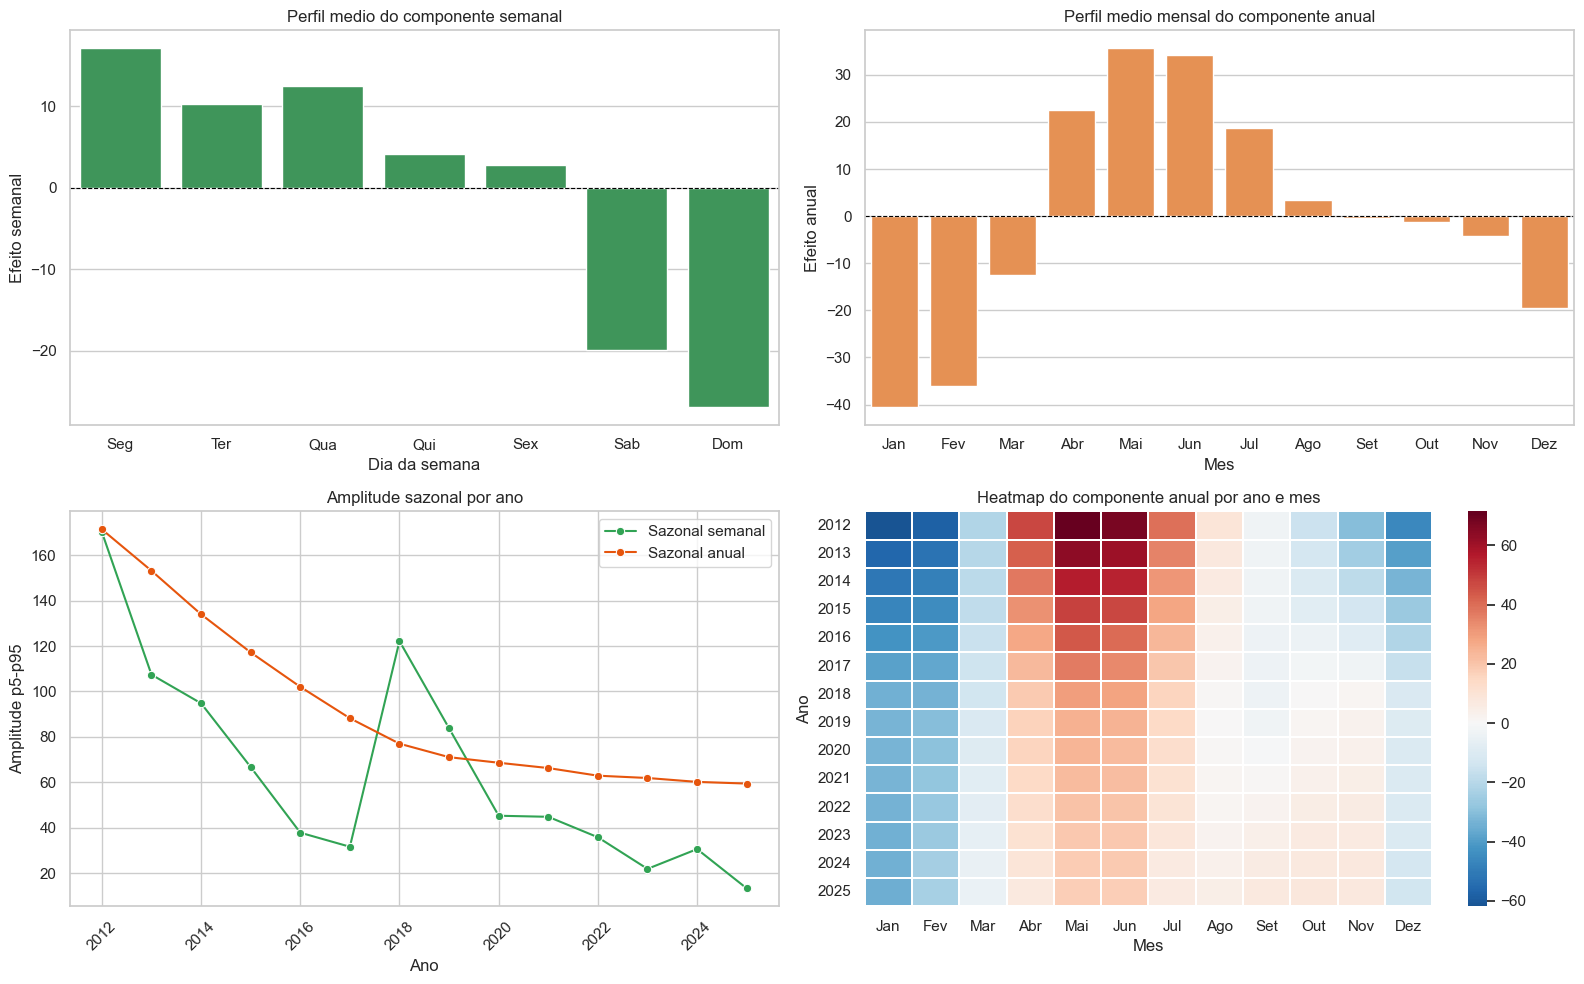

In [ ]:
perfil_sazonal_semanal = (
    df_decomp.groupby(["dia_semana_num", "dia_semana_nome"], observed=True)["sazonal_7"]
    .mean()
    .reset_index()
    .sort_values("dia_semana_num")
)

amplitude_por_ano = (
    df_decomp.groupby("ano")
    .agg(
        amplitude_tendencia=("tendencia", lambda s: s.quantile(0.95) - s.quantile(0.05)),
        amplitude_sazonal_semanal=("sazonal_7", lambda s: s.quantile(0.95) - s.quantile(0.05)),
        volatilidade_residuo=("residuo", "std"),
    )
    .reset_index()
)

display(perfil_sazonal_semanal[["dia_semana_nome", "sazonal_7"]].round(2))

if tem_sazonal_anual:
    perfil_sazonal_anual_mensal = (
        df_decomp.groupby(["mes", "mes_nome"], observed=True)["sazonal_365"]
        .mean()
        .reset_index()
        .sort_values("mes")
    )

    amplitude_sazonal_anual = (
        df_decomp.groupby("ano")["sazonal_365"]
        .apply(lambda s: s.quantile(0.95) - s.quantile(0.05))
        .rename("amplitude_sazonal_anual")
        .reset_index()
    )

    amplitude_por_ano = amplitude_por_ano.merge(amplitude_sazonal_anual, on="ano", how="left")

    heatmap_sazonal_anual = (
        df_decomp.groupby(["ano", "mes_nome"], observed=True)["sazonal_365"]
        .mean()
        .reset_index()
        .pivot(index="ano", columns="mes_nome", values="sazonal_365")
        .reindex(columns=list(meses.values()))
    )

    display(amplitude_por_ano.round(2))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    sns.barplot(data=perfil_sazonal_semanal, x="dia_semana_nome", y="sazonal_7", color="#31a354", ax=axes[0, 0])
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0, 0].set_title("Perfil medio do componente semanal")
    axes[0, 0].set_xlabel("Dia da semana")
    axes[0, 0].set_ylabel("Efeito semanal")

    sns.barplot(data=perfil_sazonal_anual_mensal, x="mes_nome", y="sazonal_365", color="#fd8d3c", ax=axes[0, 1])
    axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0, 1].set_title("Perfil medio mensal do componente anual")
    axes[0, 1].set_xlabel("Mes")
    axes[0, 1].set_ylabel("Efeito anual")

    sns.lineplot(data=amplitude_por_ano, x="ano", y="amplitude_sazonal_semanal", marker="o", color="#31a354", label="Sazonal semanal", ax=axes[1, 0])
    sns.lineplot(data=amplitude_por_ano, x="ano", y="amplitude_sazonal_anual", marker="o", color="#e6550d", label="Sazonal anual", ax=axes[1, 0])
    axes[1, 0].set_title("Amplitude sazonal por ano")
    axes[1, 0].set_xlabel("Ano")
    axes[1, 0].set_ylabel("Amplitude p5-p95")
    axes[1, 0].tick_params(axis="x", rotation=45)

    sns.heatmap(heatmap_sazonal_anual, cmap="RdBu_r", center=0, linewidths=0.1, ax=axes[1, 1])
    axes[1, 1].set_title("Heatmap do componente anual por ano e mes")
    axes[1, 1].set_xlabel("Mes")
    axes[1, 1].set_ylabel("Ano")

    plt.tight_layout()
    plt.show()
else:
    display(amplitude_por_ano.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

    sns.barplot(data=perfil_sazonal_semanal, x="dia_semana_nome", y="sazonal_7", color="#31a354", ax=axes[0])
    axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0].set_title("Perfil medio do componente semanal")
    axes[0].set_xlabel("Dia da semana")
    axes[0].set_ylabel("Efeito semanal")

    sns.lineplot(data=amplitude_por_ano, x="ano", y="amplitude_sazonal_semanal", marker="o", color="#31a354", ax=axes[1])
    axes[1].set_title("Amplitude semanal por ano")
    axes[1].set_xlabel("Ano")
    axes[1].set_ylabel("Amplitude p5-p95")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

### O que observar nesta etapa

- Se a linha de tendencia subir ou cair por periodos longos, ha evidencia de mudanca estrutural na serie.
- Se a sazonalidade semanal mantiver um desenho parecido ao longo dos anos, esse efeito e mais facil de modelar.
- Se a sazonalidade anual concentrar sinais positivos e negativos nos mesmos meses em varios anos, isso sugere padrao sazonal relativamente estavel.
- Se a amplitude sazonal variar muito entre anos, pode haver mudanca de regime ou interacao entre tendencia e sazonalidade.
- Se o residuo apresentar blocos grandes ou picos persistentes, vale investigar eventos especificos, anomalias ou quebras estruturais que o modelo sazonal nao explicou.